#### Exercise 1

<b>Task</b><br>
Create a Personalized Compliment Agent with LangGraph.
<br>
<b>Input</b>: {'name': 'Kat'}<br>
<b>Output</b>: "Kat, great job learning LangGraph!"

In [2]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

In [9]:
class AgentState(TypedDict):
    name: str
    compliment: str

def compliment_node(state: AgentState) -> AgentState:
    """Simple node that compliments the user"""
    state["compliment"] = f"{state['name']}, great job learning LangGraph!"
    return state


In [4]:
graph = StateGraph(AgentState)
graph.add_node("complimentor", compliment_node)
graph.set_entry_point("complimentor")
graph.set_finish_point("complimentor")

app = graph.compile()

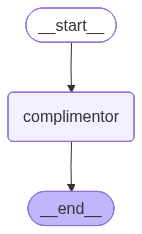

In [5]:
app

In [6]:
result = app.invoke({"name": "Kat"})

In [8]:
result["compliment"]

'Kat, great job learning LangGraph!'

---

#### Exercise 2

<b>Task</b><br>
Create a Graph that takes a list of int with a name and an operator. If the operator is '+', give the sum of the list elements. If it's '\*', give the product. Use a single node.
<br>
<b>Input</b>: {'name': 'Kat', 'values': [20, 5], 'operation': '*'}<br>
<b>Output</b>: "Hi Kat, your result is 100."

In [11]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [18]:
class AgentState(TypedDict):
    name: str
    values: List[int]
    operator: str
    result: str

def operator(state: AgentState) -> AgentState:
    """Tool to apply user operator on given list."""
    if state["operator"] == "+":
        result = sum(state["values"])
    elif state["operator"] == "*":
        result = 1
        for num in state["values"]: result *= num
    else:
        result = None

    if result:
        state["result"] = f"Hi {state['name']}, your result is {result}."
    else:
        state["result"] = f"Hi {state['name']}, your operator {state['operator']} is invalid. Please use one of '+' and '*'."
    return state

In [13]:
graph = StateGraph(AgentState)
graph.add_node("operator", operator)
graph.set_entry_point("operator")
graph.set_finish_point("operator")

app = graph.compile()

In [17]:
kats_payload = {
    "name": "Kat",
    "values": [20, 5],
    "operator": "*"
}
kats_product = app.invoke(kats_payload)

kats_product["result"]

'Hi Kat, your result is 100.'

---

#### Exercise 3

<b>Task</b>

1. Accept a user's name, age, and a list of their skills.
2. Pass the state through three nodes that:
- First node: Personalizes the name field with a greeting.
- Second node: Describes the user's age.
- Third node: Lists the user's skills in a formatted string.

3. The final output in the result field should be a combined message in this format: <br>
   Output: "Linda, welcome to the system! You are 31 years old! You have skills in: Python, Machine Learning, LangGraph"

In [21]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [35]:
class AgentState(TypedDict):
    name: str
    age: int
    skills: List[str]
    message: str

def greeting(state: AgentState) -> AgentState:
    """First node, to greet the user"""
    state["message"] = f"{state['name']}, welcome to the system!"
    return state

def get_age(state: AgentState) -> AgentState:
    """Second node, to describe the age"""
    state["message"] = f"{state['message']} You are {state['age']} years old!"
    return state

def list_skills(state: AgentState) -> AgentState:
    """Third node, to list the user skills"""
    state["message"] = f"{state['message']} You have skills in: {', '.join(state['skills'])}"
    return state

In [36]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting)
graph.add_node("get_age", get_age)
graph.add_node("list_skills", list_skills)

graph.add_edge("greeting", "get_age")
graph.add_edge("get_age", "list_skills")

graph.set_entry_point("greeting")
graph.set_finish_point("list_skills")

app = graph.compile()

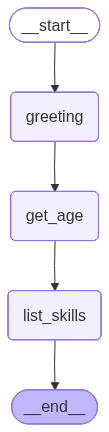

In [37]:
app

In [38]:
payload = {
    'name': 'Travis',
    'age': 30,
    'skills': ['Jupyter', 'Python', 'ML', 'AI']
}

result = app.invoke(payload, output_keys="message")
result

'Travis, welcome to the system! You are 30 years old! You have skills in: Jupyter, Python, ML, AI'

---

#### Exercise 4

<b>Task</b>
Make the graph to do operation1 on first 2 numbers and operation2 on next 2 numbers. You will need to make use of 2
conditional edges!
<br>
Input:<br>
initial_state = AgentState(number1 = 10, operation1="-", number2 = 5, number3 = 7, number4=2, operation2="+", finalNumber= 0, finalNumber2 = 0)

In [40]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [41]:
class AgentState(TypedDict):
    num1: int
    op1: str
    num2: int
    result1: int
    num3: int
    op2: str
    num4: int
    result2: int

In [48]:
def adder_1(state: AgentState) -> AgentState:
    """Add num1 and num2, store in result1"""
    state['result1'] = state['num1'] + state['num2']
    return state

def subtractor_1(state: AgentState) -> AgentState:
    """Subtract num2 from num1, store in result1"""
    state['result1'] = state['num1'] - state['num2']
    return state

def adder_2(state: AgentState) -> AgentState:
    """Add num3 and num4, store in result2"""
    state['result2'] = state['num3'] + state['num4']
    return state

def subtractor_2(state: AgentState) -> AgentState:
    """Subtract num4 from num3, store in result2"""
    state['result2'] = state['num3'] - state['num4']
    return state

def decision_1(state: AgentState) -> str:
    """Choose the edge for operation 1"""
    if state["op1"] == "+":
        return "addition_operation_1"
    elif state["op1"] == "-":
        return "subtraction_operation_1"

def decision_2(state: AgentState) -> str:
    """Choose the edge for operation 2"""
    if state["op2"] == "+":
        return "addition_operation_2"
    elif state["op2"] == "-":
        return "subtraction_operation_2"

In [49]:
graph = StateGraph(AgentState)

graph.add_node("add_node_1", adder_1)
graph.add_node("subtract_node_1", subtractor_1)
graph.add_node("add_node_2", adder_2)
graph.add_node("subtract_node_2", subtractor_2)
graph.add_node("router_1", lambda state: state)
graph.add_node("router_2", lambda state: state)

graph.add_edge(START, "router_1")
graph.add_conditional_edges(
    "router_1",
    decision_1,
    {
        "addition_operation_1": "add_node_1",
        "subtraction_operation_1": "subtract_node_1"
    }
)

graph.add_edge("add_node_1", "router_2")
graph.add_edge("subtract_node_1", "router_2")
graph.add_conditional_edges(
    "router_2",
    decision_2,
    {
        "addition_operation_2": "add_node_2",
        "subtraction_operation_2": "subtract_node_2"
    }
)

graph.add_edge("add_node_2", END)
graph.add_edge("subtract_node_2", END)

app = graph.compile()

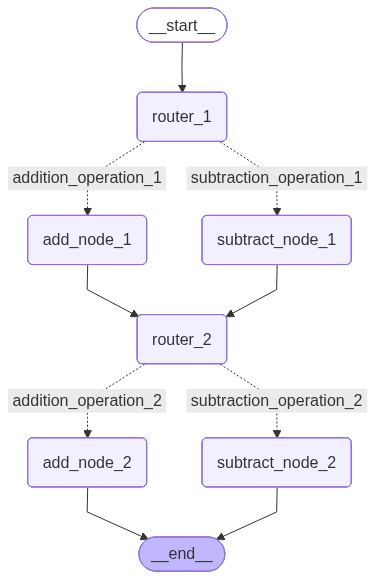

In [50]:
app

In [51]:
input_state = AgentState(num1=10, op1="+", num2=40, num3=100, op2="-", num4=40)
app.invoke(input_state)

{'num1': 10,
 'op1': '+',
 'num2': 40,
 'result1': 50,
 'num3': 100,
 'op2': '-',
 'num4': 40,
 'result2': 60}

---

#### Exercise 5

<b>Task</b>
Make the graph in the image! You need to implement an Automatic Higher or Lower Game.

Set the bounds to between 1 to 20. The Graph has to keep guessing (max number of guesses is 7) where if the guess is correct, then it stops, but if not we keep looping until we hit the max limit of 7.

Each time a number is guessed, the hint node should say higher or lower and the graph should account for this information and guess the next guess accordingly.

Input: {"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20}

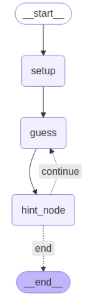

In [55]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
import random

In [54]:
class AgentState(TypedDict):
    player_name: str
    target: int
    guesses: List[int]
    attempts: int
    hint: str
    lower_bound: int
    upper_bound: int

In [65]:
def setup(state: AgentState) -> AgentState:
    """Setting up the Agent"""

    state["guesses"] = []
    state["attempts"] = 0
    state["hint"] = None
    state["target"] = random.randint(state['lower_bound'], state['upper_bound'])
    print(f"Hi {state['player_name']}, welcome to the guessing game! The target is {state['target']}")
    return state

def guess(state: AgentState) -> AgentState:
    """Make a guess"""
    if state['hint']=="higher":
        state['lower_bound'] = state['guesses'][-1]
    elif state['hint']=="lower":
        state['upper_bound'] = state['guesses'][-1]
        
    guess = random.randint(state['lower_bound'], state['upper_bound'])
    state['guesses'].append(guess)
    state['attempts'] += 1
    print(f"The guess at attemp {state['attempts']} is {guess}")
    return state

def hint(state: AgentState) -> AgentState:
    """Gives hint"""
    if state["guesses"][-1] < state["target"]:
        state["hint"] = "higher"
        print("Gotta go higher!")
    elif state["guesses"][-1] > state["target"]:
        state["hint"] = "lower"
        print("Gotta go lower!")
    else:
        state["hint"] = None
        print("It's a match!")

    return state


def guess_again(state: AgentState) -> str:
    """Choose whether to guess again or exit"""
    if state['guesses'][-1] == state['target']:
        return "exit"
    elif state['attempts'] == 7:
        print("We're out of guesses :(")
        return "exit"
    else:
        return "retry"

In [66]:
graph = StateGraph(AgentState)

graph.add_node("Setup", setup)
graph.add_node("Guess", guess)
graph.add_node("Hint", hint)

graph.add_edge(START, "Setup")
graph.add_edge("Setup", "Guess")
graph.add_edge("Guess", "Hint")
graph.add_conditional_edges(
    "Hint",
    guess_again,
    {
        "retry": "Guess",
        "exit": END
    }
)

app = graph.compile()

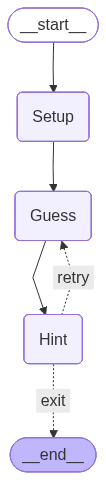

In [67]:
app

In [70]:
result = app.invoke({"player_name": "Travis", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 10})

Hi Travis, welcome to the guessing game! The target is 9
The guess at attemp 1 is 8
Gotta go higher!
The guess at attemp 2 is 9
It's a match!


---